# <center> Machine Learning in Computational Biology - Assignment #1</center>
### <center>*Spring 2026*</center>
### <center>*Epigenetic Age Prediction from DNA Methylation*</center>

---


### Libraries

In [1]:
from functions import *
sys.path.append(os.path.abspath("../src"))
print("Libraries successfully loaded")

Libraries successfully loaded


# Task 1 : Data Loading and Preprocessing
---

## 1.1 Data splitting



### a) Loading the data

In [2]:
dev_data,eval_data=loading_files("../data/development_data.csv","../data/evaluation_data.csv")

Development set (456, 1003)            age             ethnicity sex  cg16867657  cg06639320  cg24724428  \
sample_id                                                                      
GSM990554   79  Caucasian - European   M    0.672001    0.504461    0.331257   
GSM990278   46    Hispanic - Mexican   M    0.555411    0.389214    0.160708   
GSM990589   78  Caucasian - European   M    0.781318    0.554360    0.337578   
GSM990323   46    Hispanic - Mexican   F    0.542491    0.435584    0.228723   
GSM990116   59    Hispanic - Mexican   F    0.653190    0.466217    0.208453   

           cg07553761  cg22454769  cg06784991  cg21572722  ...  cg17321954  \
sample_id                                                  ...               
GSM990554    0.327287    0.572867    0.309496    0.444902  ...    0.174936   
GSM990278    0.230875    0.464971    0.223665    0.381837  ...    0.154691   
GSM990589    0.437668    0.645529    0.309615    0.505999  ...    0.213999   
GSM990323    0.231709

### b) Splitting the data
#### ~80% training - 20% validation split (stratified by age, seed=42)

In [3]:
train_data,val_data,eval_data=split_data(dev_data,eval_data)

        Split  Samples  Percentage
0       Train      364   79.824561
1  Validation       92   20.175439


## 1.2  Preprocessing

#### Checking missing values in train, val & eval sets

In [4]:
#Searching for the NA values in each data set
print("Missing values in development set")
check_missing_values(dev_data)
print("Missing values in TRAIN set")
check_missing_values(X_train)
print("Missing values in VALIDATION set")
check_missing_values(X_val)
print("Missing values in EVALUATION set")
check_missing_values(eval_data)




Missing values in development set
Total missing: 13712

Top five missing: cg26330518    32
cg25410668    28
cg15903032    25
cg01493685    25
cg12233363    25
dtype: int64
Missing values in TRAIN set


NameError: name 'X_train' is not defined

In [6]:
# Gathering feature groups
metadata,cpg,age=feature_gather(dev_data)
print("Metadata info:",metadata)
print("Info of CpG columns:",len(cpg))
print("Column of focus:",age)
print("=====================")
#Create feature sets
metadata_features = feature_set(dev_data, sets="metadata")
cpg_features = feature_set(dev_data, sets="cpg")
all_features = feature_set(dev_data, sets="all")
print("Metadata feature count:", len(metadata_features))
print("CpG feature count:", len(cpg_features))
print("All feature count:", len(all_features))

Metadata info: ['sex', 'ethnicity']
Info of CpG columns: 1000
Column of focus: age
Metadata feature count: 2
CpG feature count: 1000
All feature count: 1002


## Feature Matrices

#### _CpG feature focus_

In [7]:
# CpG feature matrix
X_train_cpg, y_train = split_feature(X_train, cpg_features, age="age")
X_val_cpg, y_val = split_feature(X_val, cpg_features, age="age")
X_eval_cpg, y_eval = split_feature(eval_data, cpg_features, age="age")

print("CpG matrix:")
print("Train_cpg:", X_train_cpg.shape)
print("Val_cpg:", X_val_cpg.shape)
print("Eval_cpg:", X_eval_cpg.shape)

print("==================================================")
#CpG preprocessing
preprocessor_cpg = preprocessor_pipeline(cpg=cpg_features, metadata=[])
X_train_cpg_processed = preprocessor_cpg.fit_transform(X_train_cpg) #only training fitting
X_val_cpg_processed = preprocessor_cpg.transform(X_val_cpg)
X_eval_cpg_processed = preprocessor_cpg.transform(X_eval_cpg)
print("Processed CpG-only")


CpG matrix:
Train_cpg: (364, 1000)
Val_cpg: (92, 1000)
Eval_cpg: (100, 1000)
Processed CpG-only


#### _Metadata feature focus_

In [8]:
#Creating a feature matrix
X_train_meta,y_train=split_feature(X_train,metadata_features,age="age")
X_val_meta,y_val=split_feature(X_val,metadata_features,age="age")
X_eval_meta,y_eval=split_feature(eval_data,metadata_features,age="age")
print("Metadata matrix:")
print("Train_metadata:", X_train_meta.shape)
print("Val_metadata:", X_val_meta.shape)
#print("Eval_meta:", X_eval_meta.shape)

print("==================================================")
#Metadata preprocessing
preprocessor_meta = preprocessor_pipeline(cpg=[], metadata=metadata_features)
X_train_meta_processed = preprocessor_meta.fit_transform(X_train_meta) #only on to be fitted
X_val_meta_processed = preprocessor_meta.transform(X_val_meta)
X_eval_meta_processed = preprocessor_meta.transform(X_eval_meta)

print("Processed Metadata matrix:")
print("Train_metadata_processed:", X_train_meta_processed.shape)
print("Val_metadata_processed:", X_val_meta_processed.shape)
print("Eval_meta_processed:", X_eval_meta_processed.shape)


Metadata matrix:
Train_metadata: (364, 2)
Val_metadata: (92, 2)
Processed Metadata matrix:
Train_metadata_processed: (364, 4)
Val_metadata_processed: (92, 4)
Eval_meta_processed: (100, 4)


### All feature matrix

In [9]:
X_train_all, y_train = split_feature(X_train, all_features, age="age")
X_val_all, y_val = split_feature(X_val, all_features, age="age")
X_eval_all, y_eval = split_feature(eval_data,all_features, age="age")

print("All features matrices:")
print("Train_all:", X_train_all.shape)
print("Val_all:", X_val_all.shape)
print("Eval_all:", X_eval_all.shape)
print("==================================================")
#All feature preprocessing together
preprocessor_all = preprocessor_pipeline(cpg=cpg_features, metadata=metadata_features)
X_train_all_processed = preprocessor_all.fit_transform(X_train_all) #fit only here
X_val_all_processed = preprocessor_all.transform(X_val_all)
X_eval_all_processed = preprocessor_all.transform(X_eval_all)
print("Processed all feature matrices:")
print("Train_all_processed:", X_train_all_processed.shape)
print("Val_all_processed:", X_val_all_processed.shape)
print("Eval_all_processed:", X_eval_all_processed.shape)



All features matrices:
Train_all: (364, 1002)
Val_all: (92, 1002)
Eval_all: (100, 1002)
Processed all feature matrices:
Train_all_processed: (364, 1004)
Val_all_processed: (92, 1004)
Eval_all_processed: (100, 1004)


## 1.3 Exploratory Analysis

In [10]:
statistics_df = stats_table(X_train,X_val,eval_data)
statistics_df

,split,n_samples,age_mean ± std,age_range,Male,Female
0,Train,364,64.5 ± 14.6,19 - 101,191,173
1,Validation,92,64.2 ± 14.7,25 - 89,41,51
2,Evaluation,100,62.5 ± 14.3,21 - 92,42,58


In [11]:
#A more informative data table of the distributions of each feature and result of missing values
train_summary = data_summary(X_train, "Train")
val_summary = data_summary(X_val, "Validation")
eval_summary = data_summary(eval_data, "Evaluation")
summary_df = pd.DataFrame([train_summary, val_summary, eval_summary])
summary_df

,dataset,samples,age_mean,age_std,age_min,age_max,sex_balance,ethnicity_balance,cpg_info,total_missing_values
0,Train,364,64.51,14.64,19,101,"{'M': 191, 'F': 173}","{'Caucasian - European': 246, 'Hispanic - Mexi...",1000,10965
1,Validation,92,64.22,14.69,25,89,"{'F': 51, 'M': 41}","{'Caucasian - European': 62, 'Hispanic - Mexic...",1000,2747
2,Evaluation,100,62.50,14.35,21,92,"{'F': 58, 'M': 42}","{'Caucasian - European': 56, 'Hispanic - Mexic...",1000,3058


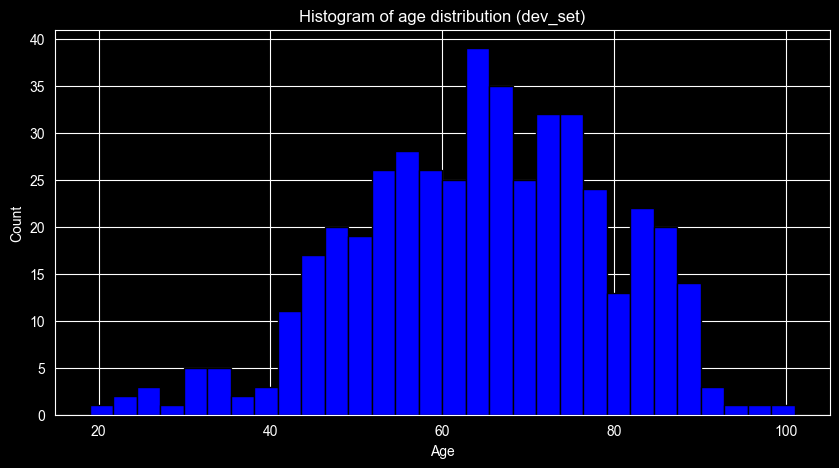

In [12]:
age_distribution_plot(dev_data["age"])

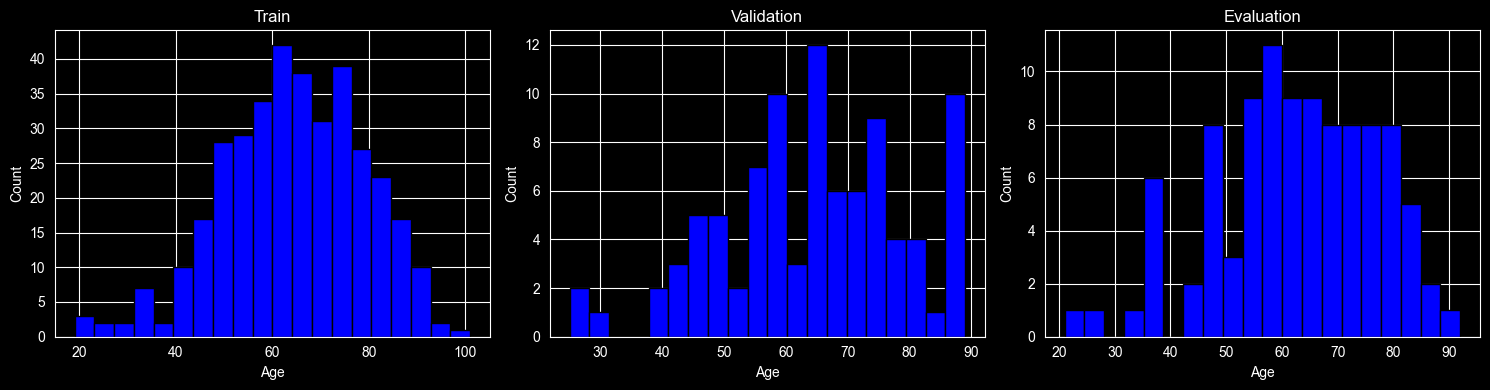

In [13]:
age_split_plot(X_train,X_val,eval_data)

---

# Task 2: Baseline Models
---

## 2.1  OLS LinearRegression across feature sets

#### Metadata


In [14]:
ols_meta_model,ols_meta_predict=ols_model(X_train_meta_processed,y_train,X_val_meta_processed)
ols_meta_results=evaluation_of_model(y_val,ols_meta_predict)

Evaluation of the model by using bootstrap
Validation metrics and 95% CI:
RMSE: 12.9545 (95% CI: 10.3478 - 14.9251)
MAE: 9.8540 (95% CI: 8.2050 - 11.5031)
R^2: 0.2138 (95% CI: 0.0706 - 0.3744)
Pearson r: 0.4629 (95% CI: 0.3346 - 0.6314)


#### CpG feature

In [15]:
ols_cpg_model, ols_cpg_predict = ols_model(X_train_cpg_processed,y_train,X_val_cpg_processed)
ols_cpg_results = evaluation_of_model(y_val,ols_cpg_predict)

Evaluation of the model by using bootstrap
Validation metrics and 95% CI:
RMSE: 5.2731 (95% CI: 4.2210 - 6.3661)
MAE: 4.0006 (95% CI: 3.3481 - 4.5064)
R^2: 0.8697 (95% CI: 0.8068 - 0.9171)
Pearson r: 0.9355 (95% CI: 0.9037 - 0.9615)


### All features

In [16]:
ols_all_model, ols_all_predict = ols_model(X_train_all_processed,y_train,X_val_all_processed)
ols_all_results = evaluation_of_model(y_val, ols_all_predict)

Evaluation of the model by using bootstrap
Validation metrics and 95% CI:
RMSE: 5.2576 (95% CI: 4.1987 - 6.3586)
MAE: 3.9915 (95% CI: 3.3598 - 4.5067)
R^2: 0.8705 (95% CI: 0.8074 - 0.9180)
Pearson r: 0.9360 (95% CI: 0.9042 - 0.9619)


## 2.2  Three regression models at default hyperparameters

In [17]:
# Results of each model
#ElasticNet
print("###########Results############")
print("\n")
print("1.ElasticNet (EN) ")
elastic_model, elastic_pred = model_elasticnet(X_train_cpg_processed,y_train,X_val_cpg_processed)
elastic_results = evaluation_of_model(y_val, elastic_pred)
#SVR
print("\n2.SVR ")
svr_model, svr_pred = svr_model(X_train_cpg_processed,y_train,X_val_cpg_processed)
svr_results = evaluation_of_model(y_val, svr_pred)
#BayesianRidge
print("\n3.BayesianRidge (BR)")
bayes_model, bayes_pred = bayesianridge_model(X_train_cpg_processed,y_train,X_val_cpg_processed)
bayes_results = evaluation_of_model(y_val, bayes_pred)

###########Results############


1.ElasticNet (EN) 
################Training of ElasticNet###############
Evaluation of the model by using bootstrap
Validation metrics and 95% CI:
RMSE: 5.5131 (95% CI: 4.3882 - 6.9163)
MAE: 4.0937 (95% CI: 3.4524 - 4.8609)
R^2: 0.8576 (95% CI: 0.7807 - 0.9050)
Pearson r: 0.9334 (95% CI: 0.8897 - 0.9606)

2.SVR 
###############Training of SVR###############
Evaluation of the model by using bootstrap
Validation metrics and 95% CI:
RMSE: 8.9233 (95% CI: 7.2354 - 10.2988)
MAE: 6.4736 (95% CI: 5.3783 - 7.5135)
R^2: 0.6270 (95% CI: 0.5577 - 0.6934)
Pearson r: 0.8464 (95% CI: 0.7941 - 0.8904)

3.BayesianRidge (BR)
###############Training of BayesianRidge model###############
Evaluation of the model by using bootstrap
Validation metrics and 95% CI:
RMSE: 4.7284 (95% CI: 3.6478 - 5.8507)
MAE: 3.5355 (95% CI: 2.9729 - 4.0808)
R^2: 0.8953 (95% CI: 0.8350 - 0.9340)
Pearson r: 0.9500 (95% CI: 0.9194 - 0.9711)


In [18]:
#Comparison table of models
comparison_table = pd.DataFrame([
    {
        "Model": "OLS",
        "RMSE": ols_cpg_results["rmse_full"],
        "MAE": ols_cpg_results["mae_full"],
        "R^2": ols_cpg_results["r2_full"],
        "Pearson_r": ols_cpg_results["pearson_full"],
    },
    {
        "Model": "EN",
        "RMSE": elastic_results["rmse_full"],
        "MAE": elastic_results["mae_full"],
        "R^2": elastic_results["r2_full"],
        "Pearson_r": elastic_results["pearson_full"],
    },
    {
        "Model": "SVR",
        "RMSE": svr_results["rmse_full"],
        "MAE": svr_results["mae_full"],
        "R^2": svr_results["r2_full"],
        "Pearson_r": svr_results["pearson_full"],
    },
    {
        "Model": "BR",
        "RMSE": bayes_results["rmse_full"],
        "MAE": bayes_results["mae_full"],
        "R^2": bayes_results["r2_full"],
        "Pearson_r": bayes_results["pearson_full"],
    }
])

comparison_table

,Model,RMSE,MAE,R^2,Pearson_r
0,OLS,5.273076,4.000551,0.869735,0.935548
1,EN,5.513114,4.093689,0.857606,0.933433
2,SVR,8.923338,6.473612,0.626962,0.846437
3,BR,4.728381,3.535510,0.895257,0.950015


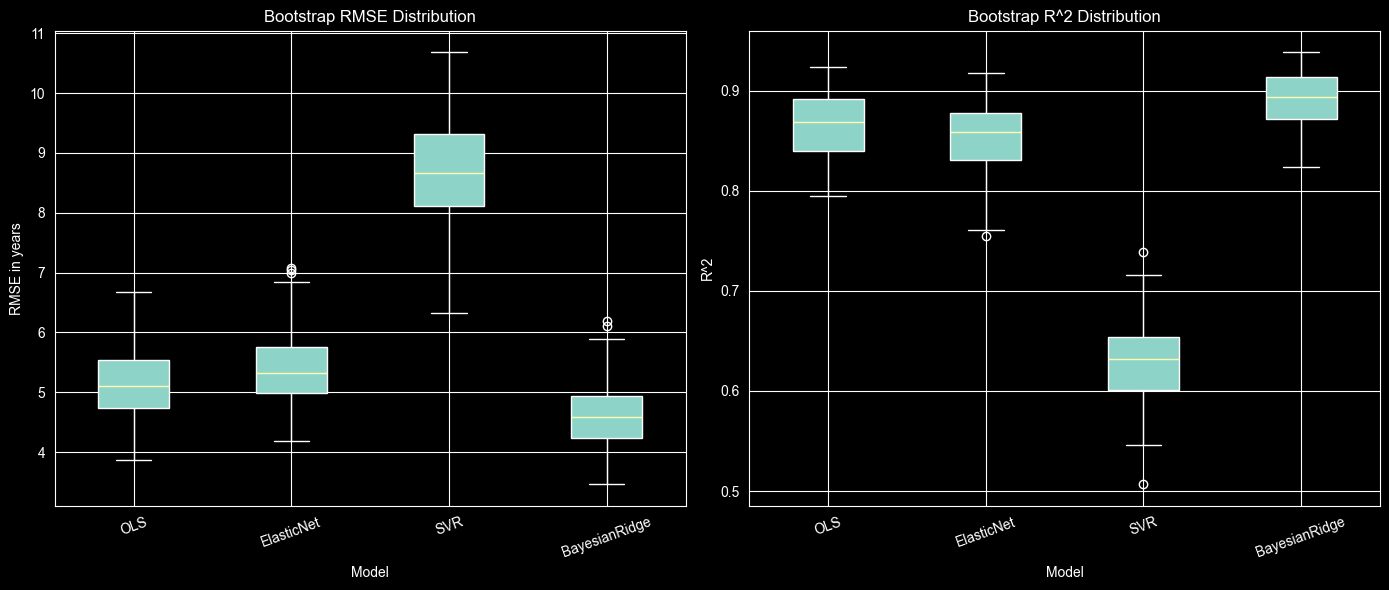

In [19]:
#Summary table for each model
results= {"OLS": ols_cpg_results, "ElasticNet": elastic_results,"SVR": svr_results,"BayesianRidge": bayes_results}
#Boxplot print
bootstrap_boxplots(results)

In [20]:
#Checking for overfitting
models = {"OLS": ols_cpg_model,"EN": elastic_model,"SVR": svr_model,"BR": bayes_model}

train_val = train_vs_val_all_models(
    models,
    X_train_cpg_processed, y_train,
    X_val_cpg_processed, y_val
)
train_val

,Model,Train RMSE,Val RMSE,Train R^2,Val R^2
0,OLS,7.348968e-14,5.273076,1.000000,0.869735
1,EN,3.841868e+00,5.513114,0.930916,0.857606
2,SVR,8.414715e+00,8.923338,0.668584,0.626962
3,BR,1.132770e+00,4.728381,0.993994,0.895257


# Task 3: Feature Selection
---

## 3.1  Stability Selection

Resample regeneration: 10/50 completed
Resample regeneration: 20/50 completed
Resample regeneration: 30/50 completed
Resample regeneration: 40/50 completed
Resample regeneration: 50/50 completed
The stable features are: 188


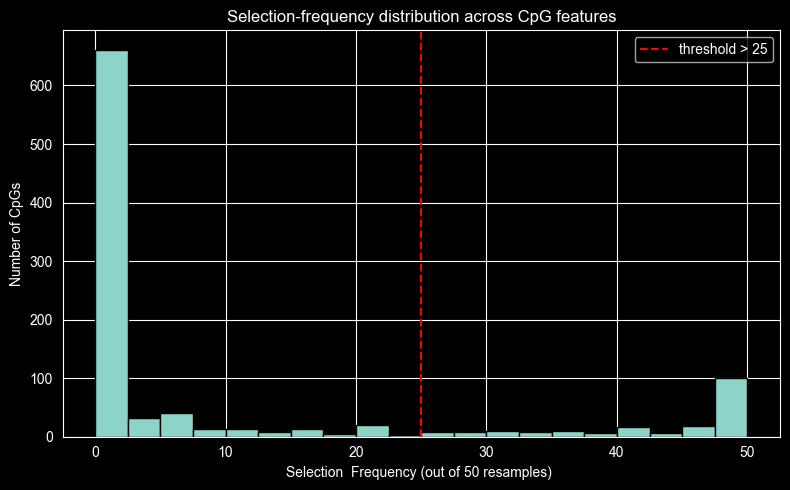

In [21]:
stable_features,selections_counts=stability_selection(X_train)
frequencyplot(selections_counts)


## 3.2   Minimum Redundancy Maximum Relevance  (mRMR)

### Choosing a K value

In [ ]:
b_k,results = choosing_k_value(X_train,X_val)
results

### Running mRMR with best choosen K

In [ ]:
mrmr_features,top10_mrmr=mrmr_function(X_train,b_k)


### Overlap between Stability & mRMR

In [ ]:
overlapping_plot(stable_features.index,mrmr_features)

## 3.3  Method comparison & Selection

In [ ]:
comparison_df,selected_features,selected_method=feature_comparison(X_train,X_val,stable_features,mrmr_features,b_k)

---

# Task 4: Hyperparameter Tuning and Final Evaluation

----

## 4.1  Hyperparameter tuning

In [ ]:
#Tuning
best_models,tuning_results=model_tuning(dev_data,selected_features,trails=40,seed=42)
tuning_results

## 4.2  Final model evaluation

### Tuned models & Results

In [ ]:
elastic_tuned_results = evaluation(best_models["ElasticNet"],eval_data,selected_features)
svr_tuned_results = evaluation(best_models["SVR"],eval_data,selected_features)
bayes_tuned_results = evaluation(best_models["BayesianRidge"],eval_data,selected_features)
# Tuned results all together
tuned_results={"ElasticNet":elastic_tuned_results,"SVR":svr_tuned_results,"BayesianRidge":bayes_tuned_results}

In [ ]:
bootstrap_boxplots_4_2(tuned_results)
scatter_plot_realvspredicted(best_models,eval_data,selected_features)

### Stage Tables

In [ ]:
elastic_fs,svr_fs,bayes_fs=fs_eval_models(X_train,X_val,selected_features)

In [ ]:
elastic_stage_results = {"Baseline": elastic_results,"FS-only": elastic_fs,"FS+Tuned": elastic_tuned_results}
elastic_stage_table = query_table("ElasticNet", elastic_stage_results)
elastic_stage_table

In [ ]:
svr_stage_results = {"Baseline": svr_results,"FS-only": svr_fs,"FS+Tuned": svr_tuned_results}
svr_stage_table = query_table("SVR", svr_stage_results)
svr_stage_table

In [ ]:
bayes_stage_results ={"Baseline":bayes_results,"Fs-only":bayes_fs,"Fs+only":bayes_tuned_results}
bayes_stage_table = query_table("BayesianRidge", bayes_stage_results)
bayes_stage_table

### Fs-only evaluation

In [ ]:
elastic_fs, svr_fs, bayes_fs = fs_eval_models(X_train,X_val,selected_features)

## 4.3  Model selection and final model

In [ ]:
tuned_results = {"ElasticNet": elastic_tuned_results,"SVR": svr_tuned_results,"BayesianRidge": bayes_tuned_results}
tuned_models = {"ElasticNet": best_models["ElasticNet"],"SVR": best_models["SVR"],"BayesianRidge": best_models["BayesianRidge"]}
best_model_name, best_model, best_model_path = selection_save_final(tuned_results=tuned_results,tuned_models=tuned_models)

## Best Model Results

In [ ]:
X_eval = eval_data[selected_features]
y_eval = eval_data["age"].values
y_predict = best_model.predict(X_eval)
plot_best_model_real_predict(y_eval, y_predict, best_model_name)